In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import ks_2samp

In [6]:
def load_data():
    df = pd.read_csv("data/prosperLoanData.csv")
    return df

def preprocess_data(df):
    target = 'LoanStatus'
    features = [col for col in df.columns if col != target]
    
    df = df.dropna(subset=[target])
    df[target] = (df[target] == 'Completed').astype(int)
    
    # Encode categorical variables
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    
    df.fillna(df.median(), inplace=True)
    
    X = df[features]
    y = df[target]
    
    return train_test_split(X, y, test_size=0.2, random_state=42)

def train_models(X_train, y_train):
    # Logistic Regression
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    logreg = LogisticRegression(max_iter=1000)
    logreg.fit(X_train_scaled, y_train)
    
    # LightGBM
    lgb_train = lgb.Dataset(X_train, label=y_train)
    params = {'objective': 'binary', 'metric': 'auc', 'verbosity': -1}
    lgbm = lgb.train(params, lgb_train, num_boost_round=100)
    
    return logreg, lgbm, scaler

def evaluate_models(models, X_test, y_test, scaler):
    logreg, lgbm = models[:2]
    X_test_scaled = scaler.transform(X_test)
    
    y_pred_logreg = logreg.predict_proba(X_test_scaled)[:, 1]
    y_pred_lgbm = lgbm.predict(X_test)
    
    auc_logreg = roc_auc_score(y_test, y_pred_logreg)
    auc_lgbm = roc_auc_score(y_test, y_pred_lgbm)
    
    ks_logreg = ks_2samp(y_pred_logreg[y_test == 1], y_pred_logreg[y_test == 0]).statistic
    ks_lgbm = ks_2samp(y_pred_lgbm[y_test == 1], y_pred_lgbm[y_test == 0]).statistic
    
    gini_logreg = 2 * auc_logreg - 1
    gini_lgbm = 2 * auc_lgbm - 1
    
    return {
        'Logistic Regression': {'AUC': auc_logreg, 'KS': ks_logreg, 'Gini': gini_logreg},
        'LightGBM': {'AUC': auc_lgbm, 'KS': ks_lgbm, 'Gini': gini_lgbm}
    }

def plot_roc(models, X_test, y_test, scaler):
    logreg, lgbm = models[:2]
    X_test_scaled = scaler.transform(X_test)
    
    y_pred_logreg = logreg.predict_proba(X_test_scaled)[:, 1]
    y_pred_lgbm = lgbm.predict(X_test)
    
    fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_pred_logreg)
    fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_pred_lgbm)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr_logreg, tpr_logreg, label='Logistic Regression')
    plt.plot(fpr_lgbm, tpr_lgbm, label='LightGBM')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.title('ROC Curve')
    plt.show()


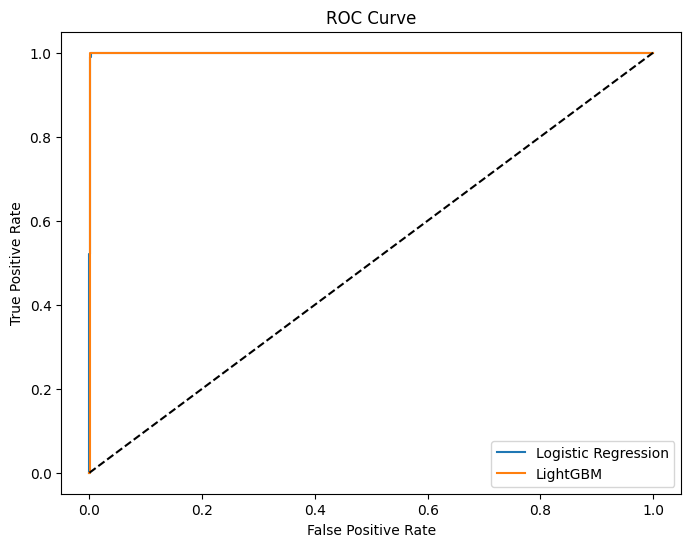

{'Logistic Regression': {'AUC': 0.9996833851306588, 'KS': 0.9956588021942482, 'Gini': 0.9993667702613176}, 'LightGBM': {'AUC': 0.9998686198515404, 'KS': 0.9998686198515404, 'Gini': 0.9997372397030808}}


In [7]:
if __name__ == "__main__":
    df = load_data()
    X_train, X_test, y_train, y_test = preprocess_data(df)
    models = train_models(X_train, y_train)
    results = evaluate_models(models, X_test, y_test, models[2])
    plot_roc(models, X_test, y_test, models[2])
    print(results)

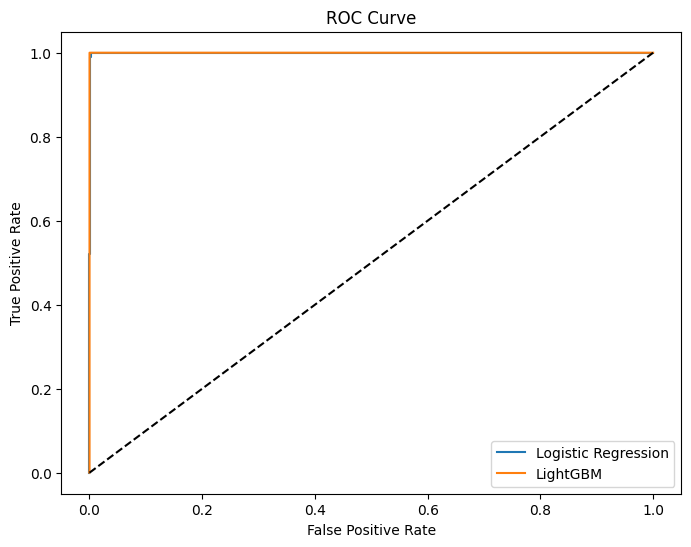

{'Logistic Regression': {'AUC': 0.9996833851306588, 'KS': 0.9956588021942482, 'Gini': 0.9993667702613176}, 'LightGBM': {'AUC': 0.9998686198515404, 'KS': 0.9998686198515404, 'Gini': 0.9997372397030808}}


In [8]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import ks_2samp

def load_data():
    df = pd.read_csv("data/prosperLoanData.csv")
    return df

def preprocess_data(df):
    target = 'LoanStatus'
    features = [col for col in df.columns if col != target]
    
    df = df.dropna(subset=[target])
    df[target] = (df[target] == 'Completed').astype(int)
    
    # Encode categorical variables
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    
    # Separate data for models
    X = df[features]
    y = df[target]
    
    # Fill missing values only for Logistic Regression (LightGBM can handle them)
    X_logreg = X.fillna(X.median())
    
    return train_test_split(X, y, test_size=0.2, random_state=42), train_test_split(X_logreg, y, test_size=0.2, random_state=42)

def train_models(X_train, X_train_logreg, y_train):
    # Logistic Regression
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_logreg)
    logreg = LogisticRegression(max_iter=1000)
    logreg.fit(X_train_scaled, y_train)
    
    # LightGBM
    lgb_train = lgb.Dataset(X_train, label=y_train)
    params = {'objective': 'binary', 'metric': 'auc', 'verbosity': -1}
    lgbm = lgb.train(params, lgb_train, num_boost_round=100)
    
    return logreg, lgbm, scaler

def evaluate_models(models, X_test, X_test_logreg, y_test, scaler):
    logreg, lgbm = models[:2]
    X_test_scaled = scaler.transform(X_test_logreg)
    
    y_pred_logreg = logreg.predict_proba(X_test_scaled)[:, 1]
    y_pred_lgbm = lgbm.predict(X_test)
    
    auc_logreg = roc_auc_score(y_test, y_pred_logreg)
    auc_lgbm = roc_auc_score(y_test, y_pred_lgbm)
    
    ks_logreg = ks_2samp(y_pred_logreg[y_test == 1], y_pred_logreg[y_test == 0]).statistic
    ks_lgbm = ks_2samp(y_pred_lgbm[y_test == 1], y_pred_lgbm[y_test == 0]).statistic
    
    gini_logreg = 2 * auc_logreg - 1
    gini_lgbm = 2 * auc_lgbm - 1
    
    return {
        'Logistic Regression': {'AUC': auc_logreg, 'KS': ks_logreg, 'Gini': gini_logreg},
        'LightGBM': {'AUC': auc_lgbm, 'KS': ks_lgbm, 'Gini': gini_lgbm}
    }

def plot_roc(models, X_test, X_test_logreg, y_test, scaler):
    logreg, lgbm = models[:2]
    X_test_scaled = scaler.transform(X_test_logreg)
    
    y_pred_logreg = logreg.predict_proba(X_test_scaled)[:, 1]
    y_pred_lgbm = lgbm.predict(X_test)
    
    fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_pred_logreg)
    fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_pred_lgbm)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr_logreg, tpr_logreg, label='Logistic Regression')
    plt.plot(fpr_lgbm, tpr_lgbm, label='LightGBM')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.title('ROC Curve')
    plt.show()

if __name__ == "__main__":
    df = load_data()
    (X_train, X_test, y_train, y_test), (X_train_logreg, X_test_logreg, _, _) = preprocess_data(df)
    models = train_models(X_train, X_train_logreg, y_train)
    results = evaluate_models(models, X_test, X_test_logreg, y_test, models[2])
    plot_roc(models, X_test, X_test_logreg, y_test, models[2])
    print(results)


In [10]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import ks_2samp

def load_data():
    df = pd.read_csv("data/prosperLoanData.csv")
    return df

def check_data_leakage(df, target):
    correlations = df.corr()[target].abs().sort_values(ascending=False)
    print("Top 10 correlated features with target:")
    print(correlations.head(10))

def preprocess_data(df):
    target = 'LoanStatus'
    features = [col for col in df.columns if col != target]
    
    df = df.dropna(subset=[target])
    df[target] = (df[target] == 'Completed').astype(int)
    
    # Check for data leakage
    check_data_leakage(df, target)
    
    # Encode categorical variables
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    
    # Separate data for models
    X = df[features]
    y = df[target]
    
    # Fill missing values only for Logistic Regression (LightGBM can handle them)
    X_logreg = X.fillna(X.median())
    
    return train_test_split(X, y, test_size=0.2, random_state=42), train_test_split(X_logreg, y, test_size=0.2, random_state=42)

def train_models(X_train, X_train_logreg, y_train):
    # Logistic Regression
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_logreg)
    logreg = LogisticRegression(max_iter=1000)
    logreg.fit(X_train_scaled, y_train)
    
    # LightGBM with regularization to prevent overfitting
    lgb_train = lgb.Dataset(X_train, label=y_train)
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'num_leaves': 31,
        'max_depth': 5,
        'min_data_in_leaf': 20,
        'learning_rate': 0.05,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 5
    }
    lgbm = lgb.train(params, lgb_train, num_boost_round=100)
    
    return logreg, lgbm, scaler

def evaluate_models(models, X_test, X_test_logreg, y_test, scaler):
    logreg, lgbm = models[:2]
    X_test_scaled = scaler.transform(X_test_logreg)
    
    y_pred_logreg = logreg.predict_proba(X_test_scaled)[:, 1]
    y_pred_lgbm = lgbm.predict(X_test)
    
    auc_logreg = roc_auc_score(y_test, y_pred_logreg)
    auc_lgbm = roc_auc_score(y_test, y_pred_lgbm)
    
    ks_logreg = ks_2samp(y_pred_logreg[y_test == 1], y_pred_logreg[y_test == 0]).statistic
    ks_lgbm = ks_2samp(y_pred_lgbm[y_test == 1], y_pred_lgbm[y_test == 0]).statistic
    
    gini_logreg = 2 * auc_logreg - 1
    gini_lgbm = 2 * auc_lgbm - 1
    
    return {
        'Logistic Regression': {'AUC': auc_logreg, 'KS': ks_logreg, 'Gini': gini_logreg},
        'LightGBM': {'AUC': auc_lgbm, 'KS': ks_lgbm, 'Gini': gini_lgbm}
    }

def plot_feature_importance(model, feature_names):
    importance = model.feature_importance()
    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    importance_df = importance_df.sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
    plt.title('Top 10 Feature Importances in LightGBM')
    plt.show()

def plot_roc(models, X_test, X_test_logreg, y_test, scaler):
    logreg, lgbm = models[:2]
    X_test_scaled = scaler.transform(X_test_logreg)
    
    y_pred_logreg = logreg.predict_proba(X_test_scaled)[:, 1]
    y_pred_lgbm = lgbm.predict(X_test)
    
    fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_pred_logreg)
    fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_pred_lgbm)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr_logreg, tpr_logreg, label='Logistic Regression')
    plt.plot(fpr_lgbm, tpr_lgbm, label='LightGBM')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.title('ROC Curve')
    plt.show()

if __name__ == "__main__":
    df = load_data()
    (X_train, X_test, y_train, y_test), (X_train_logreg, X_test_logreg, _, _) = preprocess_data(df)
    models = train_models(X_train, X_train_logreg, y_train)
    results = evaluate_models(models, X_test, X_test_logreg, y_test, models[2])
    plot_roc(models, X_test, X_test_logreg, y_test, models[2])
    plot_feature_importance(models[1], X_train.columns)
    print(results)


ValueError: could not convert string to float: '1021339766868145413AB3B'